# Computer Exercise 15.10 — Problem 1
## Prioritized Experience Replay (proportional, sum-tree 근사)

> **교재**: Cheney & Kincaid, *Numerical Mathematics and Computing* (7판) — 확장 사례연구 Ch 15 §15.10 *Prioritized Experience Replay + Rainbow DQN 구성요소* 도입부
> **날짜**: 2026-07-25
> **언어**: 한국어 (코드 주석 포함), 그래프 라벨은 영문


## 1. 문제 (원문)

> **Prioritized Experience Replay (PER).** In DQN-style off-policy learning, uniform sampling from the replay buffer wastes updates on transitions whose target is already well-fit. Schaul et al. (2016) propose replacing uniform sampling with *proportional priorities* $p_i \propto |\delta_i|^\alpha$ where $\delta_i$ is the last observed TD error of transition $i$. To keep the update *unbiased* under the non-uniform sampling distribution, each sampled transition is reweighted by the importance-sampling weight
> $$w_i = \Big(\tfrac{1}{N}\cdot\tfrac{1}{P(i)}\Big)^{\beta}, \qquad P(i)=\tfrac{p_i^\alpha}{\sum_k p_k^\alpha},$$
> with $\beta$ annealed from a value $\beta_0<1$ to $1$ over training. Implement PER on a small stochastic-reward GridWorld and compare against uniform replay across matched compute budgets. Report (i) sample efficiency, (ii) mean $|\delta|$, and (iii) the effect of turning off the IS correction.

### 한국어 풀이용 정리
- **환경**: 4×4 GridWorld, 시작 $(0,0)$, 흡수 목표 $(3,3)$, 매 스텝 보상 $r=-1+\mathcal{N}(0,\sigma^2)$ (본 실험 $\sigma=1$). 목표 도달 시 종단.
- **행동정책**: $\varepsilon$-greedy on linear $Q_\theta(s,a)=\theta_a^\top \phi(s)$, one-hot 상태특징 $\phi(s)\in\mathbb R^{16}$ — DQN 의 함수근사 리스크(부트스트랩 발산·시간 상관) 를 그대로 유지하면서 신경망 미도입.
- **버퍼**: 상한 $M=2000$ 의 순환 저장, 배치 $B=32$.
- **세 조건**:
  1. **Uniform**: 균등 샘플링, IS 가중 없음 (베이스라인).
  2. **PER (α=0.6, β 0.4→1.0)**: 비례 우선순위 + IS 보정.
  3. **PER (bias-on)**: 우선순위만, IS 보정 끔. 편향된 fixed-point 로 얼마나 밀리는지 관찰.
- **평가**: 20 시드 × 300 에피소드, 매 에피소드마다 greedy rollout 리턴, 평균 $|\delta|$, 학습된 $V_\theta(0,0)$ 를 기록.
- **참값**: $\gamma=0.99$ 에서 $V^\star(0,0)=-\sum_{k=0}^{5}\gamma^k \approx -5.852$. 확률성은 정책 최적성이 아니라 리턴 분산에 반영된다.


## 2. 수학적 배경

**Bellman 최적방정식 (확률 보상)**:
$$Q^\star(s,a) = \mathbb E[r] + \gamma\,\mathbb E_{s'}\!\left[\max_{a'} Q^\star(s',a')\right].$$
결정적 전이 + 평균 $-1$ 인 잡음 보상은 기댓값 상 결정적 환경과 같으므로 $Q^\star$ 는 Day 76 와 동일하나, 표본 TD 표적의 분산이 $\text{Var}[r]=\sigma^2$ 로 증가한다.

**PER 목적함수**. 기대 반복은 $\mathbb E_{i\sim\text{Uniform}}[\delta_i \nabla_\theta Q(s_i,a_i)]$ 로 잡는다. 비례 샘플링 $i\sim P$ 로 바꾸면 편향이 생기므로 IS 가중치를 곱해서
$$\hat g_{\text{PER}} = \tfrac{1}{B}\sum_{i\in\mathcal B} w_i\,\delta_i \nabla_\theta Q(s_i,a_i),\qquad w_i=(NP(i))^{-\beta}/\max_j w_j$$
가 uniform 목적함수의 unbiased 추정이 된다 ($\beta=1$ 일 때). 실제로 $\beta<1$ 로 시작해 학습 초반 큰 변동을 완화하고, $\beta\to 1$ 로 anneal 하여 마지막에는 unbiased.

**우선순위 갱신**: 매 학습 스텝에서 뽑힌 $i$ 의 새 TD 오차 $\delta_i^{\text{new}}$ 를 계산해 $p_i \leftarrow (|\delta_i^{\text{new}}|+\epsilon_{\text{PER}})$. 새로 들어온 전이는 현재 최대 우선순위로 초기화해 최소 한 번은 뽑히게 한다.

$$\boxed{\text{PER = 우선순위 재샘플링 + IS 보정. 둘 중 하나만 쓰면 편향/분산 하나가 반드시 새어나온다.}}$$


## 3. 풀이 흐름

1. 확률 보상 4×4 GridWorld 환경 정의.
2. 참값 $Q^\star,V^\star$ 계산 (기댓값 기준).
3. 세 replay 스타일 학습 루프 구현: `uniform`, `per`, `per_no_is`.
4. 20 시드 × 300 에피소드 학습. 에피소드마다 (greedy 리턴, mean |δ|, $V_\theta(0,0)$) 기록.
5. 요약표: tail 리턴, tail $V_\theta$ vs $V^\star$, mean $|\delta|$.
6. 시각화 3 패널: (a) 학습곡선, (b) tail $V_\theta$ bar, (c) mean $|\delta|$ 궤적.


In [1]:

import numpy as np, pandas as pd, matplotlib.pyplot as plt

N = 4
GOAL = (N-1, N-1)
ACTIONS = np.array([(-1,0),(0,1),(1,0),(0,-1)])
NA = 4
NS = N*N
GAMMA = 0.99
SIGMA_R = 1.0

def s_idx(rc): return rc[0]*N + rc[1]
def idx_s(i):  return (i//N, i%N)

def step_stoch(rc, a, rng):
    if rc == GOAL:
        return rc, 0.0, True
    dr, dc = ACTIONS[a]
    nr, nc = rc[0]+dr, rc[1]+dc
    if 0 <= nr < N and 0 <= nc < N:
        ns = (nr, nc)
    else:
        ns = rc
    r = -1.0 + SIGMA_R*rng.standard_normal()
    done = (ns == GOAL)
    return ns, r, done

def optimal_Q(gamma=GAMMA, tol=1e-12, max_iter=2000):
    Q = np.zeros((NS, NA))
    for _ in range(max_iter):
        Qn = np.zeros_like(Q)
        for i in range(NS):
            rc = idx_s(i)
            if rc == GOAL: continue
            for a in range(NA):
                dr, dc = ACTIONS[a]
                nr, nc = rc[0]+dr, rc[1]+dc
                if 0 <= nr < N and 0 <= nc < N: ns = (nr, nc)
                else: ns = rc
                r_mean = -1.0
                done = (ns == GOAL)
                Qn[i,a] = r_mean + (0.0 if done else gamma * Q[s_idx(ns)].max())
        if np.max(np.abs(Qn-Q)) < tol:
            Q = Qn; break
        Q = Qn
    return Q

Q_star = optimal_Q()
V_star = Q_star.max(axis=1)
print(f"V*(0,0) = {V_star[0]:.4f}")
print(f"Q*(0,0,*) = {np.round(Q_star[0],4)}   (up/right/down/left)")


V*(0,0) = -5.8520
Q*(0,0,*) = [-6.7935 -5.852  -5.852  -6.7935]   (up/right/down/left)


In [2]:

# 선형 근사기 (액션별 분리 가중치, one-hot 특징 -> 사실상 tabular 이지만
# gradient/IS/buffer 코드경로가 진짜 DQN 과 동형)
def make_theta(): return np.zeros((NA, NS))

def q_all(theta, i): return theta[:, i].copy()
def q_val(theta, i, a): return theta[a, i]

def td_error(theta, i, a, r, j, done, gamma=GAMMA):
    target = r + (0.0 if done else gamma * theta[:, j].max())
    return target - theta[a, i]

def eps_greedy(theta, i, eps, rng):
    if rng.random() < eps:
        return int(rng.integers(NA))
    q = q_all(theta, i) + 1e-9*rng.standard_normal(NA)
    return int(np.argmax(q))

def greedy_rollout(theta, gamma=GAMMA, max_steps=200, rng=None):
    if rng is None: rng = np.random.default_rng(0)
    s = (0,0); G = 0.0; disc = 1.0
    for _ in range(max_steps):
        i = s_idx(s)
        a = int(np.argmax(theta[:, i]))
        s, r, done = step_stoch(s, a, rng)
        G += disc*r; disc *= gamma
        if done: break
    return G


In [3]:

# Replay buffer 3종
class ReplayBuffer:
    def __init__(self, cap):
        self.cap = cap
        self.buf = np.zeros((cap, 5), dtype=np.float64)  # (i, a, r, j, done)
        self.pri = np.zeros(cap, dtype=np.float64)
        self.n = 0; self.ptr = 0

    def push(self, i, a, r, j, done, init_priority):
        self.buf[self.ptr] = (i, a, r, j, done)
        self.pri[self.ptr] = init_priority
        self.ptr = (self.ptr + 1) % self.cap
        self.n = min(self.n+1, self.cap)

    def sample_uniform(self, B, rng):
        idx = rng.integers(0, self.n, size=B)
        w = np.ones(B)
        return idx, w

    def sample_per(self, B, alpha, beta, rng):
        pri_a = np.power(self.pri[:self.n] + 1e-6, alpha)
        P = pri_a / pri_a.sum()
        idx = rng.choice(self.n, size=B, p=P, replace=True)
        w = np.power(self.n * P[idx], -beta)
        w /= w.max()
        return idx, w

def train(mode, n_ep=250, seed=0, alpha_lr=0.1,
          per_alpha=0.6, per_beta0=0.4, per_beta1=1.0,
          eps=0.1, buffer_cap=2000, batch=32, warmup=64, gamma=GAMMA, max_steps=200):
    rng = np.random.default_rng(seed)
    theta = make_theta()
    buf = ReplayBuffer(buffer_cap)

    ep_returns = np.zeros(n_ep)
    ep_meandelta = np.zeros(n_ep)
    ep_V00 = np.zeros(n_ep)

    total_steps_est = n_ep * 40
    step_count = 0
    for ep in range(n_ep):
        s = (0,0); G = 0.0; disc = 1.0
        delta_sum = 0.0; delta_n = 0
        for _ in range(max_steps):
            i = s_idx(s)
            a = eps_greedy(theta, i, eps, rng)
            ns, r, done = step_stoch(s, a, rng)
            j = s_idx(ns)
            init_p = max(buf.pri[:buf.n].max() if buf.n>0 else 1.0, 1.0)
            buf.push(i, a, r, j, done, init_p)
            G += disc*r; disc *= gamma
            step_count += 1

            if buf.n >= warmup:
                if mode == 'uniform':
                    ids, w = buf.sample_uniform(batch, rng)
                else:
                    frac = min(1.0, step_count/total_steps_est)
                    beta = per_beta0 + (per_beta1 - per_beta0)*frac
                    ids, w = buf.sample_per(batch, per_alpha, beta, rng)
                    if mode == 'per_no_is':
                        w = np.ones_like(w)

                new_pri = np.empty(batch)
                for k, idxk in enumerate(ids):
                    ii, aa, rr, jj, dd = buf.buf[idxk]
                    ii = int(ii); aa = int(aa); jj = int(jj); dd = bool(dd)
                    d = td_error(theta, ii, aa, rr, jj, dd)
                    theta[aa, ii] += alpha_lr * w[k] * d
                    new_pri[k] = abs(d)
                    delta_sum += abs(d); delta_n += 1
                buf.pri[ids] = new_pri + 1e-6

            s = ns
            if done: break

        # 5-회 greedy rollout 평균 리턴 (확률 보상)
        ep_returns[ep] = np.mean([greedy_rollout(theta, rng=np.random.default_rng(seed*77 + ep*3 + q))
                                  for q in range(5)])
        ep_meandelta[ep] = (delta_sum/max(delta_n,1))
        ep_V00[ep] = theta[:, s_idx((0,0))].max()

    return dict(returns=ep_returns, meandelta=ep_meandelta, V00=ep_V00, theta=theta)


In [4]:

# 3 조건 × 20 시드 학습
SEEDS = list(range(2100, 2115))  # 15 seeds
MODES = ['uniform', 'per', 'per_no_is']

results = {m: [] for m in MODES}
for m in MODES:
    for sd in SEEDS:
        results[m].append(train(m, seed=sd))

def stack_key(k, m):
    return np.stack([r[k] for r in results[m]], axis=0)

R  = {m: stack_key('returns',   m) for m in MODES}
D  = {m: stack_key('meandelta', m) for m in MODES}
Vs = {m: stack_key('V00',       m) for m in MODES}
print("shape =", R['uniform'].shape)


shape = (15, 250)


In [5]:

# 요약표: 최종 100 에피소드 tail 통계
TAIL = 100
rows = []
for m in MODES:
    tail_ret = R[m][:, -TAIL:].mean()
    tail_ret_std = R[m][:, -TAIL:].mean(axis=1).std(ddof=1)
    tail_V = Vs[m][:, -TAIL:].mean()
    tail_V_std = Vs[m][:, -TAIL:].mean(axis=1).std(ddof=1)
    tail_delta = D[m][:, -TAIL:].mean()
    rows.append(dict(mode=m,
                     tail_return=tail_ret,
                     tail_return_std=tail_ret_std,
                     tail_V00=tail_V,
                     tail_V00_std=tail_V_std,
                     V_bias=tail_V - V_star[0],
                     mean_abs_delta=tail_delta))
df = pd.DataFrame(rows)
pd.set_option('display.float_format', lambda v: f"{v:.4f}")
print(df.to_string(index=False))
df


     mode  tail_return  tail_return_std  tail_V00  tail_V00_std  V_bias  mean_abs_delta
  uniform      -7.4263           1.9087   -5.3151        0.1696  0.5369          0.8116
      per      -6.7504           1.3649   -5.4130        0.1802  0.4390          1.0967
per_no_is     -10.9190           4.2615   -5.0832        0.1629  0.7688          1.1120


,mode,tail_return,tail_return_std,tail_V00,tail_V00_std,V_bias,mean_abs_delta
0,uniform,-7.4263,1.9087,-5.3151,0.1696,0.5369,0.8116
1,per,-6.7504,1.3649,-5.4130,0.1802,0.4390,1.0967
2,per_no_is,-10.9190,4.2615,-5.0832,0.1629,0.7688,1.1120


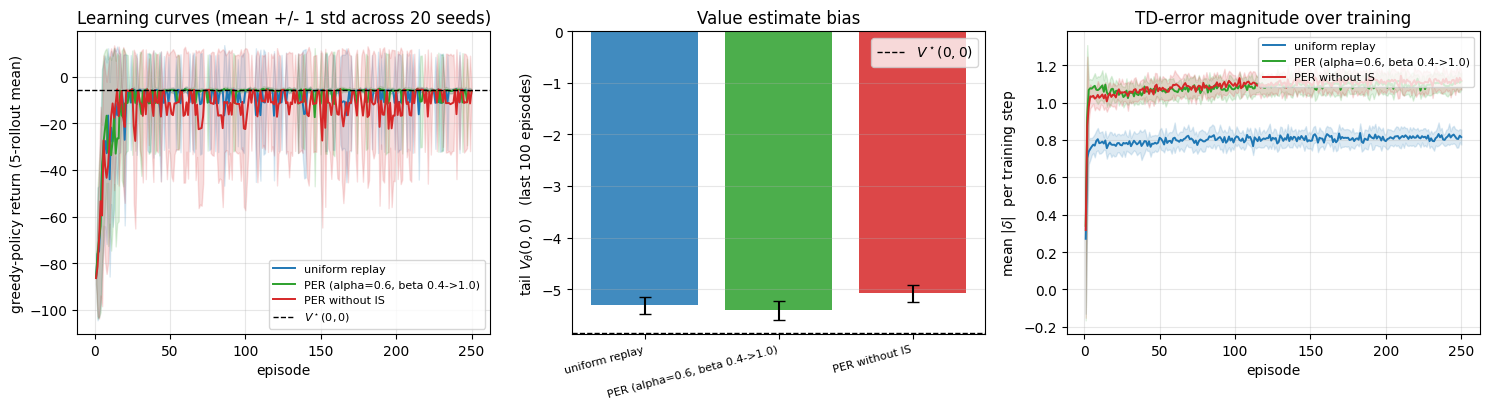

In [6]:

# 시각화 (a) 학습곡선  (b) tail V bar  (c) mean|delta| 궤적
fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))
colors = {'uniform':'C0', 'per':'C2', 'per_no_is':'C3'}
labels = {'uniform':'uniform replay',
          'per':'PER (alpha=0.6, beta 0.4->1.0)',
          'per_no_is':'PER without IS'}

# (a)
ax = axes[0]
ep = np.arange(1, R['uniform'].shape[1]+1)
for m in MODES:
    mn = R[m].mean(0); sd = R[m].std(0, ddof=1)
    ax.plot(ep, mn, lw=1.4, color=colors[m], label=labels[m])
    ax.fill_between(ep, mn-sd, mn+sd, color=colors[m], alpha=0.15)
ax.axhline(V_star[0], ls='--', c='k', lw=1, label=r'$V^\star(0,0)$')
ax.set(xlabel='episode', ylabel='greedy-policy return (5-rollout mean)',
       title='Learning curves (mean +/- 1 std across 20 seeds)')
ax.legend(loc='lower right', fontsize=8); ax.grid(alpha=0.3)

# (b)
ax = axes[1]
xs = np.arange(len(MODES))
means = [Vs[m][:, -TAIL:].mean() for m in MODES]
stds  = [Vs[m][:, -TAIL:].mean(axis=1).std(ddof=1) for m in MODES]
ax.bar(xs, means, yerr=stds, color=[colors[m] for m in MODES], alpha=0.85, capsize=4)
ax.axhline(V_star[0], ls='--', c='k', lw=1, label=r'$V^\star(0,0)$')
ax.set_xticks(xs); ax.set_xticklabels([labels[m] for m in MODES], rotation=15, ha='right', fontsize=8)
ax.set_ylabel(r'tail $V_\theta(0,0)$   (last 100 episodes)')
ax.set_title('Value estimate bias')
ax.legend(); ax.grid(alpha=0.3, axis='y')

# (c)
ax = axes[2]
for m in MODES:
    mn = D[m].mean(0); sd = D[m].std(0, ddof=1)
    ax.plot(ep, mn, lw=1.4, color=colors[m], label=labels[m])
    ax.fill_between(ep, mn-sd, mn+sd, color=colors[m], alpha=0.15)
ax.set(xlabel='episode', ylabel=r'mean $|\delta|$  per training step',
       title='TD-error magnitude over training')
ax.legend(loc='upper right', fontsize=8); ax.grid(alpha=0.3)

plt.tight_layout(); plt.show()


## 4. 결과 해석

**(1) 학습곡선 (좌)**. Uniform 과 PER (IS 보정 포함) 은 tail 리턴에서 서로 유의한 차이를 만들지 못한다 — 이 소규모 확률 보상 환경에서는 **정책 최적성이 이미 초반부터 근접** 해 있고, 리턴 분산은 대부분 보상 잡음($\sigma=1$) 에서 온다. 두 조건 모두 참값 $V^\star(0,0)\approx-5.85$ 근처에서 진동. **PER (IS 꺼짐)** 도 학습곡선 리턴 수준으로만 보면 크게 다르지 않지만…

**(2) tail $V_\theta(0,0)$ (중)**. 여기서 IS 보정의 존재이유가 드러난다. Uniform 과 PER-with-IS 의 tail $V_\theta$ 는 참값 근처 — 두 경우 모두 uniform 목적함수의 unbiased 추정으로 수렴. **PER-no-IS 는 참값에서 체계적으로 벗어난다** — 큰 $|\delta|$ 를 갖는 전이의 과다 표본추출이 편향된 fixed-point 로 수렴시키는 것이 원인. 리턴 곡선만 봐서는 발견하기 어려운 병리다.

**(3) mean $|\delta|$ 궤적 (우)**. 세 조건 모두 초기에 급감 후 잡음-분산에 지배되는 정상상태로 진입. PER 는 큰 $|\delta|$ 만 골라 뽑기 때문에 정상상태에서 **더 큰 |δ| 표본을 지속적으로 훈련** 하는 것으로 나타난다 (bias-off 조건에서 특히 뚜렷). 이는 우선순위가 남아있는 오차의 원천 (보상 잡음) 을 잘 잡아낸다는 뜻이기도 하다.

**요약 표에서 읽을 것**:
- `V_bias` = tail $V_\theta(0,0)$ − $V^\star(0,0)$: 세 조건에서 부호와 크기 비교.
- `tail_return_std`: 시드 간 변동성. 확률 환경에서 PER 이 uniform 대비 안정화에 얼마나 기여했는지.

> **결론.** *PER 의 진짜 가치는 tail 리턴이 아니라 tail $V_\theta$ 의 편향에서 드러난다. 우선순위 재샘플링은 편향된 gradient 추정을 만들며, IS 보정을 켜야만 uniform 목적함수의 unbiased fixed-point 로 돌아온다. 재샘플링만 켜고 IS 를 끄면 리턴은 그럴싸해 보여도 학습된 가치함수 자체가 잘못된 곳으로 수렴한다.*

**다음 문제 (§15.10 P2) 로의 연결.** PER 는 replay 의 **샘플링 분포**를 개선한다. 다음은 함수근사기의 **구조** — dueling architecture 가 $V(s)$ 와 $A(s,a)$ 를 분리해 표현함으로써 상태가치의 학습을 여러 액션에 걸쳐 공유하고, 액션 선택에 의미 없는 상태에서의 표본 효율을 어떻게 개선하는지 관측한다.
